In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob, scipy
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax_cosmo as jc

import optax
from optax.losses import huber_loss
from flax import nnx
import orbax.checkpoint as ocp
import jraph

import diffrax
from diffrax import diffeqsolve, ODETerm, LeapfrogMidpoint, PIDController, SaveAt, ConstantStepSize, StepTo

import jaxpm
from jaxpm import camels, plotting, hpm, nn, graph, diagnostics, objectives, training
from jaxpm.painting import cic_paint, cic_read, compensate_cic, cic_paint_2d
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm.utils import power_spectrum, cross_correlation_coefficients, refine_time_steps
from jaxpm.nn import MLP, ConditionedCNN
from jaxpm.objectives import ParticleLoss, FieldLoss

print(jax.default_backend())

/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


gpu


# configuration

In [3]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
# mesh_per_dim = 2 * parts_per_dim

# parts_per_dim = 128
# mesh_per_dim = parts_per_dim

# parts_per_dim = None
# mesh_per_dim = 256

mesh_shape = [mesh_per_dim] * 3
box_size = [float(mesh_per_dim)] * 3

# CAMELS

In [4]:
CODE = "SIMBA"
# CODE = "ASTRID"
# CODE = "IllustrisTNG"

vali_dict = camels.load_CV_snapshots(
    "CV_1",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=None,
    CAMELS="/pscratch/sd/a/athomsen/flatiron/CAMELS",
    CODE=CODE,
)

Loaded /pscratch/sd/a/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_1/parts=64,mesh=64.h5


In [5]:
cosmo = vali_dict["cosmo"]
solve_ode = training.get_ode_solver(mesh_per_dim, cosmo)

# loss

### CAMELS ground truth

In [6]:
# general
cosmo = vali_dict["cosmo"]
scales = vali_dict["scales"]

# particles
dm_poss = vali_dict["dm_poss"]
dm_vels = vali_dict["dm_vels"]

gas_poss = vali_dict["gas_poss"]
gas_vels = vali_dict["gas_vels"]

# # fields
# dm_mass = cosmo.Omega_c / (cosmo.Omega_b + cosmo.Omega_c)
# gas_mass = 1 - dm_mass

# rhos_dm = vcic_paint(jnp.zeros(mesh_shape), dm_poss, dm_mass)
# deltas_dm = rhos_dm/rhos_dm.mean() - 1

# rhos_gas = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
# deltas_gas = rhos_gas/rhos_gas.mean() - 1

# # power spectrum
# _, cls_dm = objectives.vpower_spectrum(deltas_dm)
# _, cls_gas = objectives.vpower_spectrum(deltas_gas)

# gravity correction

In [7]:
gravity_model = nn.NeuralSplineFourierFilterNNX(n_knots=8, d_latent=16, rngs=nnx.Rngs(0))
gravity_loss_fn = ParticleLoss(mesh_per_dim, w_pos=1.0, w_cls=1.0, loss_type="huber", robust_scale=mesh_per_dim//8, k_max=2)

In [8]:
checkpoint_file = os.path.join("/global/homes/a/athomsen/flatiron/JaxPM/dev/hpm/sims", f"checkpoints/gravity_fourier_spline_parts={parts_per_dim},mesh={mesh_per_dim}.jx")
checkpointer = ocp.StandardCheckpointer()

abstract_model = nnx.eval_shape(lambda: gravity_model)
graphdef, abstract_params = nnx.split(abstract_model)

params = checkpointer.restore(checkpoint_file, abstract_params)
gravity_model = nnx.merge(graphdef, params)
print(f"successfully restored model from {checkpoint_file}")

successfully restored model from /global/homes/a/athomsen/flatiron/JaxPM/dev/hpm/sims/checkpoints/gravity_fourier_spline_parts=64,mesh=64.jx


/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1269: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


# pressure correction

### MLP

In [9]:
# pressure_model = MLP(
#     d_in=5 + with_latent,
#     d_out=1 + with_latent, 
#     # d_hidden=16, 
#     d_hidden=64, 
#     # d_hidden=128,
#     # d_hidden=256,
#     n_hidden=4, 
#     # n_hidden=2, 
#     # dropout_rate=0.01,
#     dropout_rate=0.0,
#     rngs=nnx.Rngs(0),
#     norm_type="layer",
#     # norm_type="batch",
#     activation=jax.nn.swish,
#     k_filter="spline",
# )

# # learning_rate = 1e-3
# learning_rate = 1e-4
# # learning_rate = 1e-5

### CNN

In [10]:
pressure_model = ConditionedCNN(
    d_in=4, 
    d_out=1,
    d_hidden=64,
    n_hidden=4,
    kernel_size=(3, 3, 3),
    rngs=nnx.Rngs(0),
    norm_type="layer",
    activation=jax.nn.swish,
    use_residual=True,
)

# learning_rate = 1e-5
learning_rate = 1e-4

In [11]:
# see https://flax.readthedocs.io/en/latest/guides/checkpointing.html
# checkpoint_file = os.path.join("/global/homes/a/athomsen/flatiron/JaxPM/dev/hpm/sims", "checkpoints/cnn_evo_v1.jx")
# checkpoint_file = os.path.join("/global/homes/a/athomsen/flatiron/JaxPM/dev/hpm/sims", "checkpoints/cnn_evo_v2.jx")
checkpoint_file = os.path.join("/global/homes/a/athomsen/flatiron/JaxPM/dev/hpm/sims", "checkpoints/cnn_evo_v3.jx")
checkpointer = ocp.StandardCheckpointer()

abstract_model = nnx.eval_shape(lambda: pressure_model)
graphdef, abstract_params = nnx.split(abstract_model)

params = checkpointer.restore(checkpoint_file, abstract_params)
pressure_model = nnx.merge(graphdef, params)

In [12]:
i_plot = np.linspace(0, 33, 4, dtype=int)

ref_gas_poss = gas_poss[i_plot]

In [13]:
i_loss = np.linspace(8, 33, 4, dtype=int)
print(scales[i_loss])

[0.30267933 0.44367839 0.65035996 1.        ]


In [14]:
i0 = 0
y0 = (dm_poss[i0], dm_vels[i0], gas_poss[i0], gas_vels[i0])
t0 = scales[i0]
tsave = scales[i_plot]

pm_res = solve_ode(
    y0, t0, tsave, gravity_model=None, pressure_model=None, training=False, nt=2, tstep=scales
)
pm_dm_poss, pm_dm_vels, pm_gas_poss, pm_gas_vels = pm_res

hpm_res = solve_ode(
    # y0, t0, tsave, gravity_model=gravity_model, pressure_model=pressure_model, training=False, nt=2, tstep=scales
    y0, t0, tsave, gravity_model=None, pressure_model=pressure_model, training=False, nt=2, tstep=scales
)
hpm_dm_poss, hpm_dm_vels, hpm_gas_poss, hpm_gas_vels = hpm_res

Solving ODE in 100 steps (StepTo with 2 steps between ts)
dark matter and gas
dark matter and gas
dark matter and gas
Solving ODE in 100 steps (StepTo with 2 steps between ts)
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable


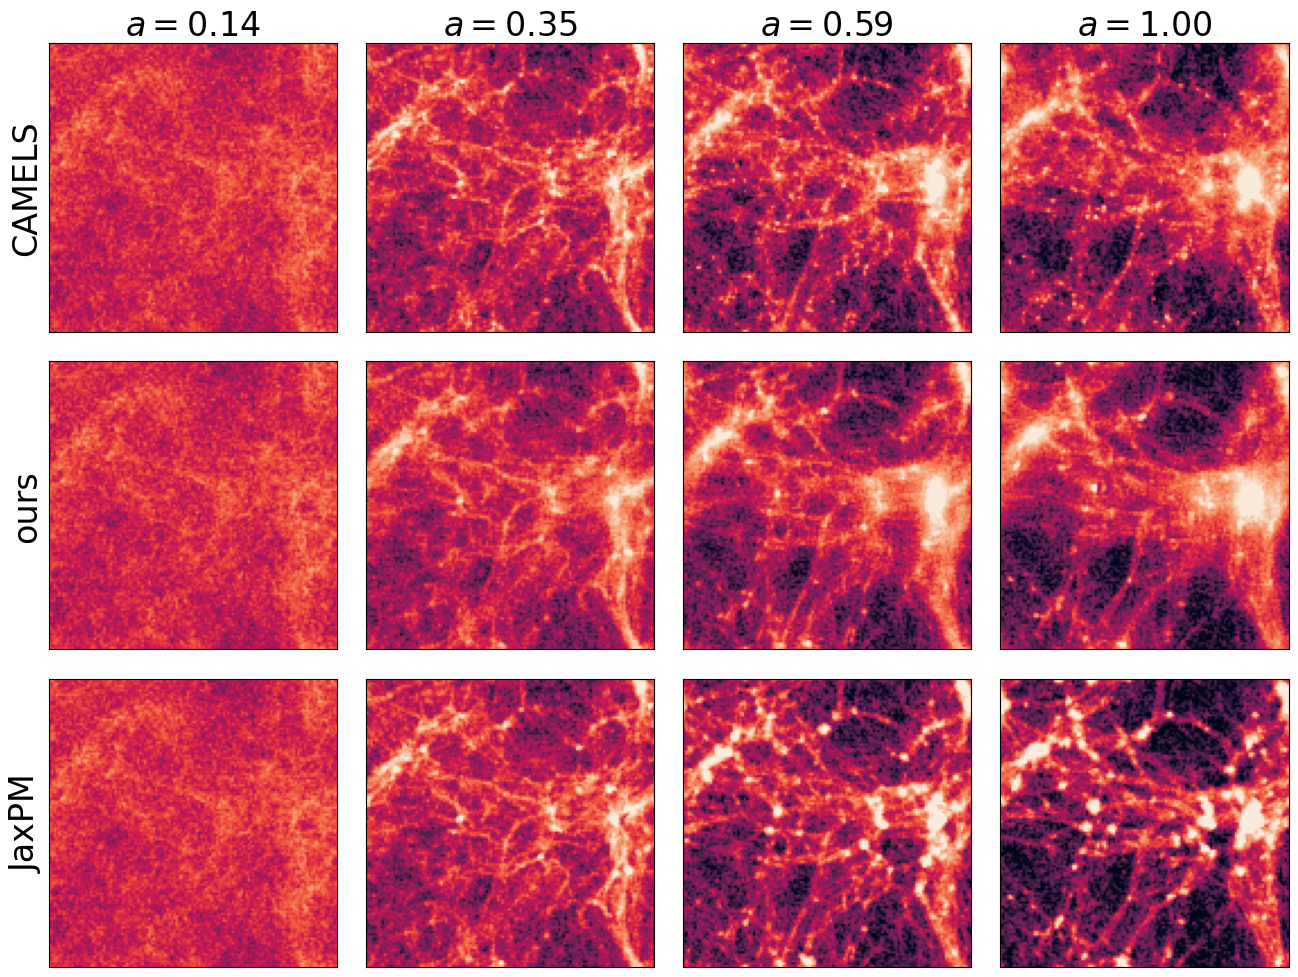

In [15]:
from matplotlib.colors import LogNorm

nrows = 3
ncols = len(i_plot)

poss = [ref_gas_poss, hpm_gas_poss, pm_gas_poss]

plot_mesh = 128
fields = np.zeros((nrows, ncols, plot_mesh, plot_mesh))
empty_mesh = jnp.zeros((plot_mesh,) * 2)
for i in range(nrows):
    for j in range(ncols):
        pos = poss[i][j]
        fields[i,j] = cic_paint_2d(empty_mesh, pos[:,[1,2]] * (plot_mesh // mesh_per_dim))

vmin = np.percentile(fields, 1)
vmax = np.percentile(fields, 99)
norm = LogNorm(vmin=vmin, vmax=vmax)

fig, ax = plt.subplots(nrows=3, ncols=ncols, figsize=(4*ncols, 4*nrows))
fig.subplots_adjust(wspace=0.1, hspace=0.1)

for i in range(nrows):
    for j in range(ncols):
        ax[i,j].imshow(fields[i,j], norm=norm, cmap="rocket")
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])

ylabels = ["CAMELS", "ours", "JaxPM"]
for i in range(nrows):
    ax[i,0].set_ylabel(ylabel=ylabels[i], fontsize=24)

for j in range(ncols):
    ax[0,j].set_title(r"$a = " + f"{scales[i_plot[j]]:.2f}" + r"$", fontsize=24)

fig.savefig(f"plots/evolution_2d_fields_mesh={mesh_per_dim}_gas.pdf", bbox_inches="tight", pad_inches=0, dpi=300)

Solving ODE in 100 steps (StepTo with 2 steps between ts)
dark matter and gas
dark matter and gas
dark matter and gas
Solving ODE in 100 steps (StepTo with 2 steps between ts)
dark matter and gas
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
dark matter and gas
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
dark matter and gas
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable


100%|██████████| 4/4 [00:10<00:00,  2.56s/it]


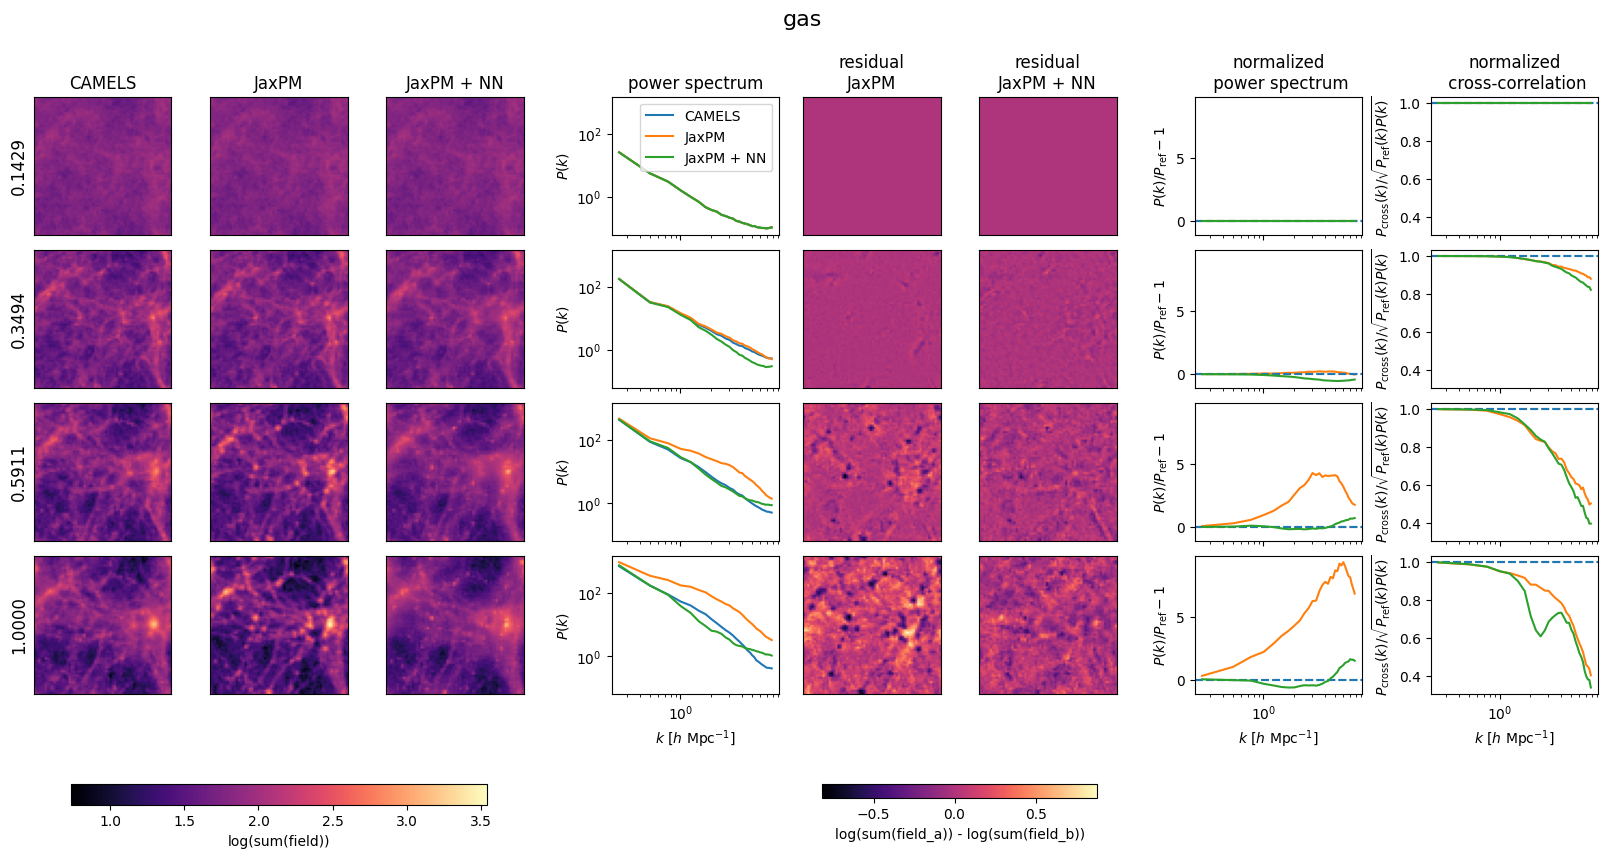

In [15]:
diagnostics.run_simulations(
    vali_dict,
    mesh_per_dim,
    gravity_model=gravity_model,
    pressure_model=pressure_model,
    nt=2,
    i_init=0,
    i_plot=i_plot,
    plot_gas=True,
)